# 13.1 图像增广（Image Augmentation）

## 1. 应用场景（为什么要做）
图像增广是在**不额外采集数据**的前提下，人工制造“看起来不同但语义相同”的训练样本。

常见场景：
- **小数据集分类**：减少过拟合（如医疗影像、工业缺陷检测）。
- **目标位置不固定**：通过随机裁剪/翻转提升位置鲁棒性。
- **光照与颜色变化大**：通过颜色扰动提升泛化能力。

核心原则：
- 训练集可用随机增广；
- 验证/测试集通常不用随机增广（只做确定性预处理）。

In [7]:
%matplotlib inline
import torch
import torchvision
from d2l import torch as d2l

# %run ../my_utils.py

## 2. 图像增广效果展示

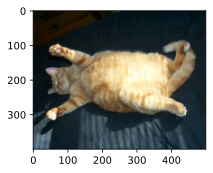

In [8]:
d2l.set_figsize()
img = d2l.Image.open('../img/cat1.jpg')
d2l.plt.imshow(img)


def apply_aug(img, aug, num_rows=2, num_cols=4, scale=1.5):
    """重复应用增广并可视化。
    - img: PIL 图片
    - aug: torchvision.transforms 中的一个变换或组合变换
    """
    Y = [aug(img) for _ in range(num_rows * num_cols)]
    d2l.show_images(Y, num_rows, num_cols, scale=scale)

### 2.1 翻转与裁剪
代码解释：
- `RandomHorizontalFlip()`：以 0.5 概率左右翻转。
- `RandomVerticalFlip()`：以 0.5 概率上下翻转（任务相关，不一定总是合理）。
- `RandomResizedCrop(...)`：先随机裁一块，再缩放到固定尺寸，增强尺度/位置鲁棒性。

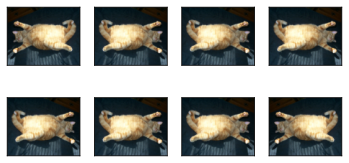

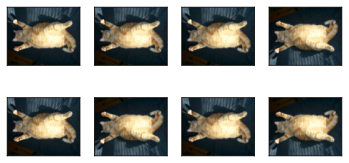

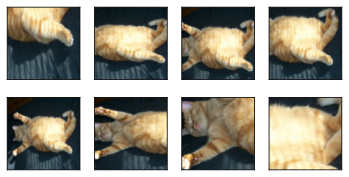

In [9]:
# 左右翻转
apply_aug(img, torchvision.transforms.RandomHorizontalFlip())

# 上下翻转
apply_aug(img, torchvision.transforms.RandomVerticalFlip())

# 随机裁剪 + 缩放到 200x200
shape_aug = torchvision.transforms.RandomResizedCrop(
    size=(200, 200), scale=(0.1, 1.0), ratio=(0.5, 2.0)
)
apply_aug(img, shape_aug)

### 2.2 颜色扰动
代码解释：
- `ColorJitter` 可随机改变亮度/对比度/饱和度/色调。
- 参数如 `brightness=0.5` 表示在原值附近做随机缩放（范围约为 $[1-0.5, 1+0.5]$）。

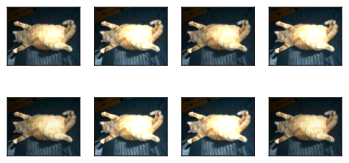

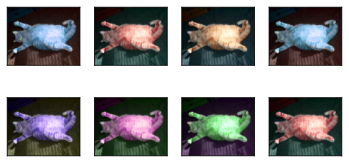

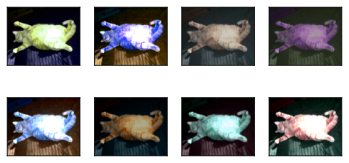

In [10]:
# 仅亮度变化
apply_aug(
    img,
    torchvision.transforms.ColorJitter(
        brightness=0.5, contrast=0, saturation=0, hue=0
    )
)

# 仅色调变化
apply_aug(
    img,
    torchvision.transforms.ColorJitter(
        brightness=0, contrast=0, saturation=0, hue=0.5
    )
)

# 联合颜色扰动
color_aug = torchvision.transforms.ColorJitter(
    brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5
)
apply_aug(img, color_aug)

### 2.3 组合增广
在真实训练中，通常把多个增广串联，覆盖“几何变化 + 颜色变化”。

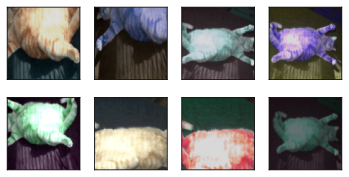

In [11]:
augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(),
    color_aug,
    shape_aug,
])
apply_aug(img, augs)

## 3. 使用方法（训练流程中怎么接）

推荐模板：
1. `train_augs` 放随机操作（flip/crop/color jitter）；
2. `test_augs` 只放确定性变换（resize/center crop/tensor/normalize）；
3. 在 `Dataset(..., transform=...)` 处接入。

下面给出最小可用代码：

In [12]:
# 训练集：随机增广 + 张量化
train_augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
])

# 测试集：仅张量化（不引入随机性）
test_augs = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])


def load_cifar10(is_train, augs, batch_size=128):
    """把增广挂到数据读取阶段。
    - is_train=True 时通常 shuffle=True
    - transform=augs 是增广生效入口
    """
    dataset = torchvision.datasets.CIFAR10(
        root='../data', train=is_train, transform=augs, download=True
    )
    return torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=is_train,
        num_workers=d2l.get_dataloader_workers(),
    )

# 用法示例（只构建迭代器，不立刻训练）
train_iter = load_cifar10(True, train_augs, batch_size=256)
test_iter = load_cifar10(False, test_augs, batch_size=256)
len(train_iter), len(test_iter)

Files already downloaded and verified
Files already downloaded and verified


(196, 40)